In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("heart.csv")

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.Sex = df.Sex.replace({'M':0,'F':1})

In [5]:
df.ST_Slope.value_counts()

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

In [6]:
df.ChestPainType = df.ChestPainType.replace({"ASY":0,"NAP":1,"ATA":2,"TA":3})
df.RestingECG = df.RestingECG.replace({"Normal":0,"LVH":1,"ST":2})
df.ExerciseAngina = df.ExerciseAngina.replace({"N":0,"Y":1})
df.ST_Slope = df.ST_Slope.replace({"Flat":0,"Up":1,"Down":2})

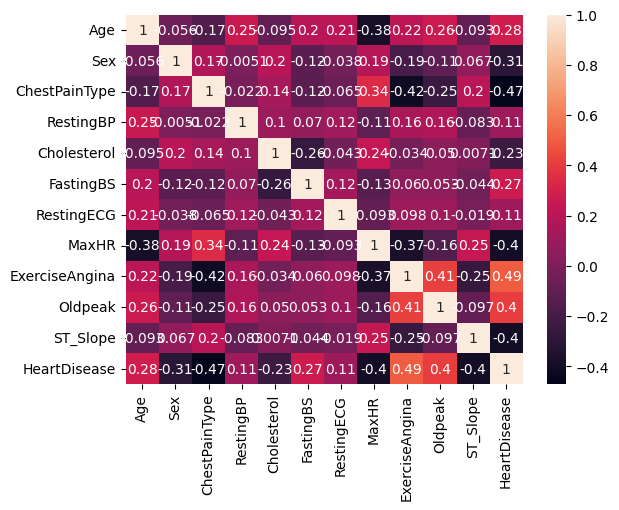

In [7]:
sns.heatmap(data=df.corr(numeric_only=True),annot=True)
plt.show()

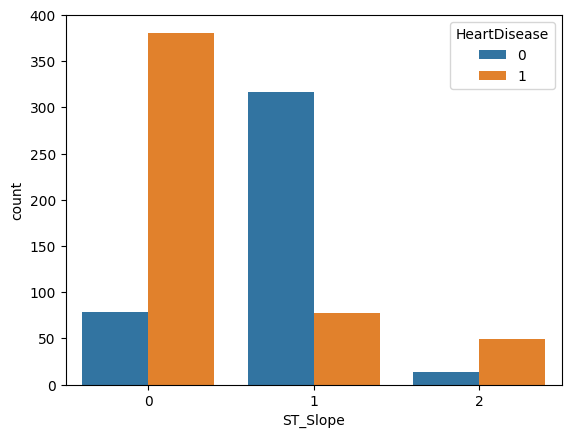

In [8]:
sns.countplot(data=df, x=df.ST_Slope          ,hue=df.HeartDisease)
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [10]:
X = df.drop(columns=["HeartDisease"], axis=1)
y = df.HeartDisease

In [11]:
x_train, x_test, y_train, y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [12]:
col_scale = ['Age', 'RestingBP','Cholesterol','MaxHR']
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [14]:
model_lr = LogisticRegression()
model_lr.fit(x_train_scaled,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [15]:
y_pred_lr = model_lr.predict(x_test_scaled)

In [16]:
model_svm = SVC()
model_svm.fit(x_train_scaled,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [17]:
y_pred_svm = model_svm.predict(x_test_scaled)

In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [19]:
print(f"accuracy_score: {accuracy_score(y_pred_lr, y_test)}")
print(f"confusion_matrix: {confusion_matrix(y_pred_lr, y_test)}")
print(f"classification_report: {classification_report(y_pred_lr, y_test)}")

accuracy_score: 0.8586956521739131
confusion_matrix: [[70 19]
 [ 7 88]]
classification_report:               precision    recall  f1-score   support

           0       0.91      0.79      0.84        89
           1       0.82      0.93      0.87        95

    accuracy                           0.86       184
   macro avg       0.87      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



In [20]:
print(f"accuracy_score: {accuracy_score(y_pred_svm, y_test)}")
print(f"confusion_matrix: {confusion_matrix(y_pred_svm, y_test)}")
print(f"classification_report: {classification_report(y_pred_svm, y_test)}")

accuracy_score: 0.8641304347826086
confusion_matrix: [[65 13]
 [12 94]]
classification_report:               precision    recall  f1-score   support

           0       0.84      0.83      0.84        78
           1       0.88      0.89      0.88       106

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



In [21]:
model_rfc = RandomForestClassifier(n_estimators=100,max_depth=5,random_state=42)
model_rfc.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
y_pred_rfc = model_rfc.predict(x_test)

In [23]:
print(f"accuracy_score: {accuracy_score(y_pred_rfc, y_test)}")
print(f"confusion_matrix: {confusion_matrix(y_pred_rfc, y_test)}")
print(f"classification_report: {classification_report(y_pred_rfc, y_test)}")

accuracy_score: 0.8967391304347826
confusion_matrix: [[69 11]
 [ 8 96]]
classification_report:               precision    recall  f1-score   support

           0       0.90      0.86      0.88        80
           1       0.90      0.92      0.91       104

    accuracy                           0.90       184
   macro avg       0.90      0.89      0.89       184
weighted avg       0.90      0.90      0.90       184



In [24]:
model_knn = KNeighborsClassifier(n_neighbors=7)
model_knn.fit(x_train_scaled,y_train)

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [25]:
y_pred_knn = model_knn.predict(x_test_scaled)

In [26]:
print(f"accuracy_score: {accuracy_score(y_pred_knn, y_test)}")
print(f"confusion_matrix: {confusion_matrix(y_pred_knn, y_test)}")
print(f"classification_report: {classification_report(y_pred_knn, y_test)}")

accuracy_score: 0.8586956521739131
confusion_matrix: [[71 20]
 [ 6 87]]
classification_report:               precision    recall  f1-score   support

           0       0.92      0.78      0.85        91
           1       0.81      0.94      0.87        93

    accuracy                           0.86       184
   macro avg       0.87      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184



In [27]:
import xgboost

In [28]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
xgb = XGBClassifier()
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    verbose=2,
    n_jobs=-1
)
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [29]:
y_pred_xgb = grid_search.predict(x_test)

In [30]:
print(f"accuracy_score: {accuracy_score(y_pred_xgb, y_test)}")
print(f"confusion_matrix: {confusion_matrix(y_pred_xgb, y_test)}")
print(f"classification_report: {classification_report(y_pred_xgb, y_test)}")

accuracy_score: 0.8913043478260869
confusion_matrix: [[67 10]
 [10 97]]
classification_report:               precision    recall  f1-score   support

           0       0.87      0.87      0.87        77
           1       0.91      0.91      0.91       107

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



In [31]:
import pickle

In [32]:
with open('heart_desiese_model.pkl', 'wb') as f:
    pickle.dump(model_rfc, f)

In [33]:
x_train.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope'],
      dtype='object')

In [34]:
df.ChestPainType.value_counts()

ChestPainType
0    496
1    203
2    173
3     46
Name: count, dtype: int64